In [ ]:

from google.colab import files
uploaded = files.upload()

Saving phishing.csv to phishing (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv('/content/phishing.csv')

print("Dataset Loaded Successfully")

# Show first 5 rows
print(df.head())

Dataset Loaded Successfully
   Index  UsingIP  LongURL  ShortURL  Symbol@  Redirecting//  PrefixSuffix-  \
0      0        1        1         1        1              1             -1   
1      1        1        0         1        1              1             -1   
2      2        1        0         1        1              1             -1   
3      3        1        0        -1        1              1             -1   
4      4       -1        0        -1        1             -1             -1   

   SubDomains  HTTPS  DomainRegLen  ...  UsingPopupWindow  IframeRedirection  \
0           0      1            -1  ...                 1                  1   
1          -1     -1            -1  ...                 1                  1   
2          -1     -1             1  ...                 1                  1   
3           1      1            -1  ...                -1                  1   
4           1      1            -1  ...                 1                  1   

   AgeofDomain  

In [ ]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(11054, 32)

Column Names:
Index(['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//',
       'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon',
       'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL',
       'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL',
       'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
       'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
       'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage',
       'StatsReport', 'class'],
      dtype='object')

Missing Values:
Index                  0
UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL            

In [ ]:
X = df.drop('class', axis=1)

y = df['class']

print("\nInput Shape:", X.shape)
print("Output Shape:", y.shape)


Input Shape: (11054, 31)
Output Shape: (11054,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (8843, 31)
Testing Data Shape: (2211, 31)


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [ ]:
predictions = model.predict(X_test)

print("\nPrediction Completed")


Prediction Completed


In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", accuracy)


Model Accuracy: 0.9696969696969697


In [ ]:
print("\nClassification Report:\n")

print(classification_report(y_test, predictions))


Classification Report:

              precision    recall  f1-score   support

          -1       0.97      0.96      0.97       976
           1       0.97      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



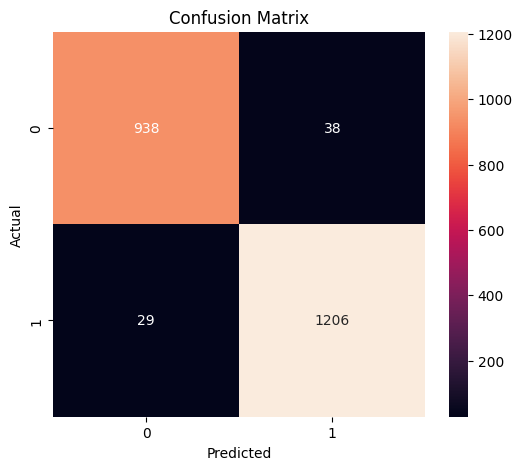

In [ ]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

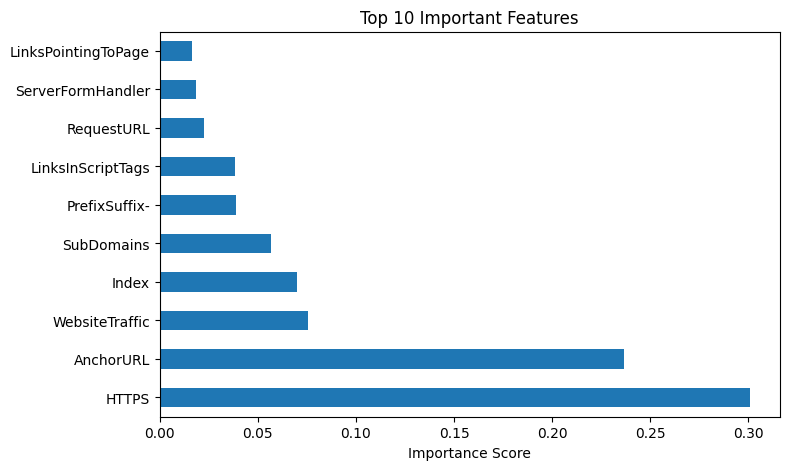

In [ ]:
importance = model.feature_importances_

feature_names = X.columns

feature_importance = pd.Series(
    importance,
    index=feature_names
)

top_features = feature_importance.nlargest(10)

plt.figure(figsize=(8,5))

top_features.plot(kind='barh')

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.show()

In [ ]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print("\nSample Prediction Result:", prediction)

if prediction[0] == 1:
    print("Legitimate Website")
else:
    print("Phishing Website")


Sample Prediction Result: [-1]
Phishing Website


In [ ]:
import joblib

joblib.dump(model, 'phishing_detection_model.pkl')

print("\nModel Saved Successfully")


Model Saved Successfully


In [ ]:
# Example Test Data

test_data = [[
    0,   # Index (added to match the 31 features the model was trained on)
    -1,  # having_IP_Address
     1,  # URL_Length
     1,  # Shortining_Service
    -1,  # having_At_Symbol
    -1,  # double_slash_redirecting
    -1,  # Prefix_Suffix
    -1,  # having_Sub_Domain
     1,  # SSLfinal_State
     1,  # Domain_registeration_length
    -1,  # Favicon
     1,  # port
    -1,  # HTTPS_token
    -1,  # Request_URL
    -1,  # URL_of_Anchor
    -1,  # Links_in_tags
     1,  # SFH
    -1,  # Submitting_to_email
    -1,  # Abnormal_URL
     1,  # Redirect
     1,  # on_mouseover
     1,  # RightClick
     1,  # popUpWidnow
     1,  # Iframe
    -1,  # age_of_domain
    -1,  # DNSRecord
    -1,  # web_traffic
    -1,  # Page_Rank
     1,  # Google_Index
     1,  # Links_pointing_to_page
    -1   # Statistical_report
]]

# Predict

prediction = model.predict(test_data)

# Output Result

if prediction[0] == 1:
    print("Legitimate Website")
else:
    print("Phishing Website")

Phishing Website


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
url = input("Enter Website URL: ")

# Simple phishing checks

phishing_score = 0

# Check for @ symbol
if "@" in url:
    phishing_score += 1

# Check for long URL
if len(url) > 75:
    phishing_score += 1

# Check for HTTPS
if "https" not in url:
    phishing_score += 1

# Check for hyphen
if "-" in url:
    phishing_score += 1

# Final Result

if phishing_score >= 2:
    print("⚠️ Phishing Website Detected")
else:
    print("✅ Legitimate Website")

Enter Website URL: https://google.com
✅ Legitimate Website


In [ ]:
url = input("Enter Website URL: ")

# Simple phishing checks

phishing_score = 0

# Check for @ symbol
if "@" in url:
    phishing_score += 1

# Check for long URL
if len(url) > 75:
    phishing_score += 1

# Check for HTTPS
if "https" not in url:
    phishing_score += 1

# Check for hyphen
if "-" in url:
    phishing_score += 1

# Final Result

if phishing_score >= 2:
    print("⚠️ Phishing Website Detected")
else:
    print("✅ Legitimate Website")

Enter Website URL: http://paypal-security-update-login.com
⚠️ Phishing Website Detected
